# Project 5 - Image denoising

## Introduction

### Image noise

Image noise is usally a distortion or inconsitentcy in the pixels of an image. There's a specific type of image noise that we call *salt and pepper noise*, which looks like exactly how it seems. There are randomly placed pixels that are black and white. In the image below is what it can look like.

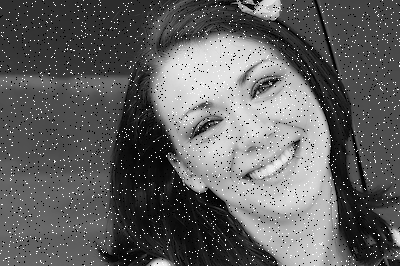

### Denoising images

Denoising images is doing the opposite of  adding noise to an image. We are taking noise out of an image to make the image more clear. There are a few formulas that we can do this with, however specifically we're applying two formulas, a **Mean Filter** and a **Median Filter**.

#### Mean Filter

$$\ m = \frac{1}{n}\sum_{i=1}^n x_i $$

The mean fiter, basically takes an odd numbered *m x m* square grid, where each square represents a color, on a scale from 0 to 1. Each of these sqaures have their own numberic expression of a color. The mean filter takes all of the representations of color and finds what is the average number expression of the color would be. 

Whatever the outcome of that number is, would replace what the center square in the grid would be, whcih in turn changes the color of the center square

Now, with an image, if we were to apply the mean filter on the whole image, it would be repeated the number of times of pixles there are in the image.

example, if we have an array like one below:

\begin{split}\begin{bmatrix}
0.8 & 0.3 & 0.2 \\
0.5 & 0.7 & 0.3 \\
0.5 & 0.5 & 0.8 \\
\end{bmatrix}\end{split}

This array would be representing a singular pixel of an image, where the pixel we are changing is the center `0.7` one. To figure out what we're changing the pixel to, we take every number in the array, and find the mean of it, which will end up being ~.51. Now, .51 will be the value of that center pixel in the original image.

#### Median Filter

Although the Medium filter has another formula and method of completing, overall, the method is almost the same. It takes the same (typically, but not necessarily) odd numbered *m x m* 2-dimensional array, similar to the mean filter. However, instead of finding what the average numberic value, the purpose, as titled, is to find the medium value, or median. 

If we do an example with the same array from earlier:

\begin{split}\begin{bmatrix}
0.8 & 0.3 & 0.2 \\
0.5 & 0.7 & 0.3 \\
0.5 & 0.5 & 0.8 \\
\end{bmatrix}\end{split}

The median value of it would be, `.5`. Although these examples, I've shown you don't have very different results, with arrays with different values and/or number of values, the results will differ. 

### Working with images

Before dealing with the noise of an image, since we are only dealing with black and white images, we need to default each of these images to black and white, even when we are first given a colorful one. The function below, `find_img` does this. 

In [530]:
import numpy as np
import matplotlib.pyplot as plt

In [531]:
def find_img(an_image):                 #takes an image
    pic = plt.imread(an_image)          #puts the image as the variable pic
    grey_image = pic[:,:,0]             #puts the image with 0 as a color value as the grey_image variable
    plt.imshow(grey_image)            
    return grey_image                   #returns the image

To show how this function works, heres an example using the `face.png` file below:

array([[0.1882353 , 0.1882353 , 0.1882353 , ..., 0.25490198, 0.25490198,
        0.2509804 ],
       [0.18431373, 0.1882353 , 0.1882353 , ..., 0.25490198, 0.25490198,
        0.2509804 ],
       [0.18431373, 0.18431373, 0.18431373, ..., 0.25490198, 0.25490198,
        0.25490198],
       ...,
       [0.40784314, 0.40784314, 0.4117647 , ..., 0.10980392, 0.10196079,
        0.09411765],
       [0.4117647 , 0.4117647 , 0.4117647 , ..., 0.11372549, 0.09803922,
        0.09019608],
       [0.4117647 , 0.4117647 , 0.40392157, ..., 0.10588235, 0.09803922,
        0.09411765]], dtype=float32)

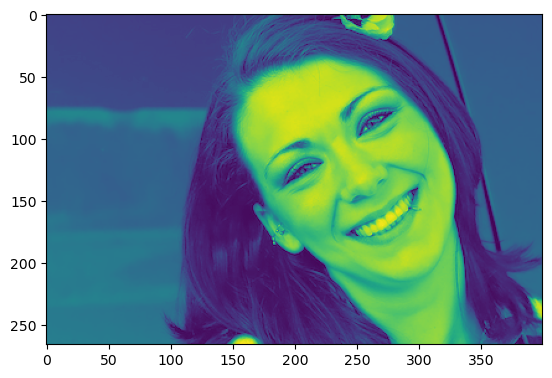

In [532]:
find_img('face.png')

As you can see, even though the color value is set to `0`, the picture is not quite at black an white. The next function below is going to deal with that

## Adding noise to images

### Adding salt and pepper to images

To add salt and pepper noise, as before, the method is randomly adding both black and white pixels to an image. To do this we are using the `sp_noise` funtion which will add a certain percentage of salt and pepper pixels to the image put into the parameter.

In [533]:
import numpy as np
import matplotlib.pyplot as plt

In [534]:
face = plt.imread('face.png')

In [535]:
def sp_noise(img, noise): 
    gray_image = find_img(img)                               #sets image variable as a 2 dim array
    (nrows,ncols) = gray_image.shape                         #sets image array variables as nrows and ncols
    pepper_mask = np.random.rand(nrows,ncols) < (noise/2)    #sets the pepper mask variable as half of the percentage of
                                                             #the noise variable
    image_noise = gray_image.copy()                          #sets the variable image_noise as a copy of the 2-dim array
    image_noise[pepper_mask] = 0                             #sets the pepper noise in the image value as 0(black)
    salt_mask = np.random.rand(nrows,ncols) > (1-noise/2)    #sets the salt mask variable as half of the percentage of
                                                             #the noise variable
    image_noise[salt_mask] = 1                               #sets the salt noise in the image value as 1(white)
    plt.imshow(image_noise, cmap = 'gray')                   #shows the image with noise with a color map as gray

Now, we can see the examples of the function on some other images, `face.png`, `boston.png`, `ciruit.png`, `motorbike.png`, `hamburg.png`, and `sign.png`

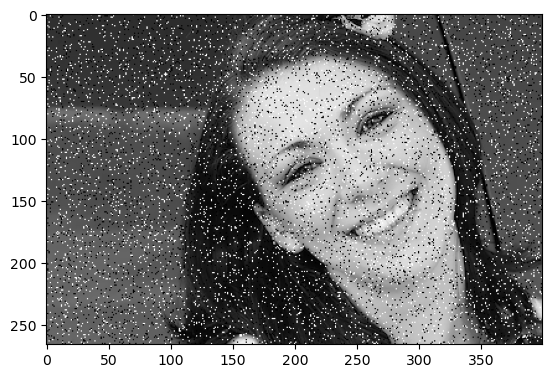

In [536]:
sp_noise('face.png', .1)                                    #applies the function sp_noise onto the image `face.png`

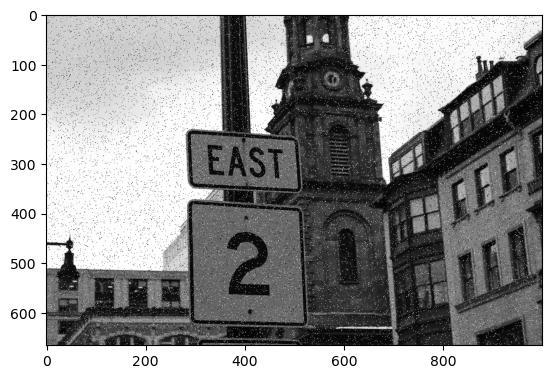

In [537]:
sp_noise('boston.png',.05)                                    #applies the function sp_noise onto the `boston.png` image

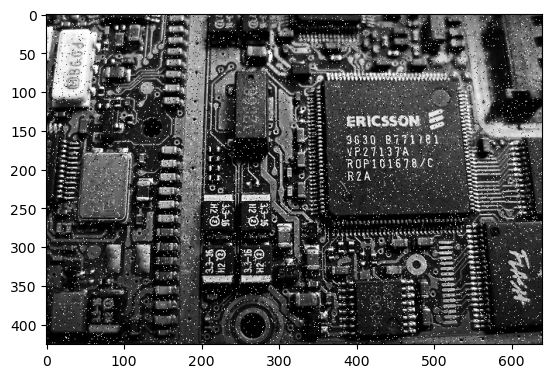

In [538]:
sp_noise('circuit.png', .05)                                 #applies the function sp_noise onto the `circuit.png` image

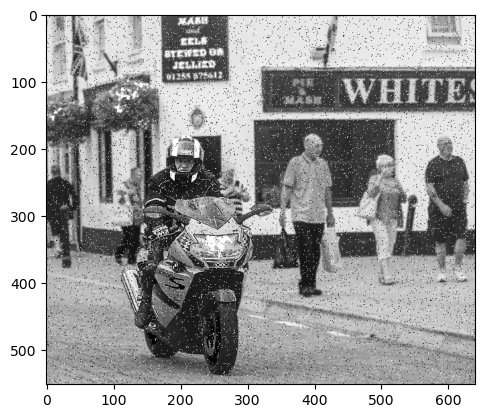

In [539]:
sp_noise('motorbike.png',.05)                              #applies the function sp_noise onto the `motorbike.png` image

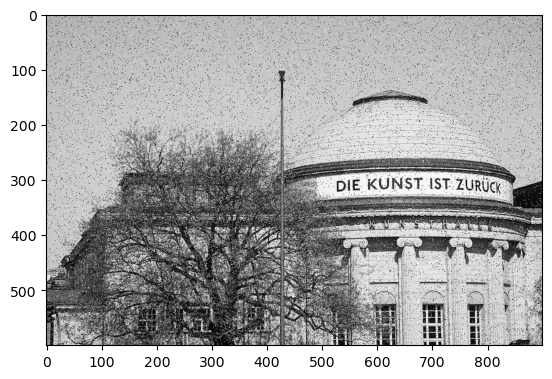

In [540]:
sp_noise('hamburg.png',.05)                       #applies the function sp_noise onto the `hamburg.png` image

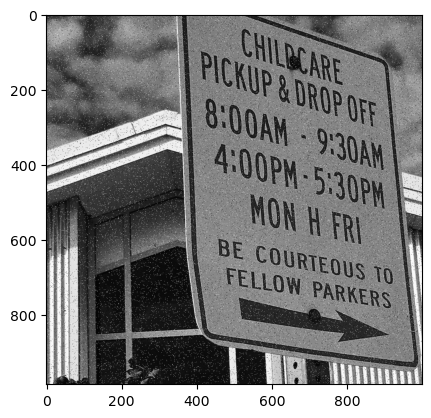

In [541]:
sp_noise('sign.png',.05)                          #applies the function sp_noise with the `sign.png` image

As we can see, the salt and pepper added to each of the images dont look the same, nor are the placed in the same locations. This is because each image has a different amount of pixels expressed in their *n x m* array, the placement of the noise is also random every time it is run, so although there's a change that the *salt and pepper* noise could be in the same places, it would be merely by coincidence.

## Denoising Images

To denoise an image, we are trying to take away the black and white salt and pepper noise pixels in the image.

### Mean Filter

The first method we're going to be using to try to eliminate noise from an image is going to be by using a **mean filter**. A mean filter, as explained earlier in the introduction, is going through each pixel one-by-one and finding the mean of the color values, of the surrounding pixels, ultimately altering the original pixel and therfore, altering the original image. Ultimately the goal is for the picture to have less noise, however, this is only the first of two methods, so we will see what differences arrive.

To be able to use the mean filter, we'll be using the function `mean_filter` which will be altering the image as a way of denoising it, and will return both the altered array and the image.

In [555]:
import math                                             #imports the math module

In [543]:
def mean_filter(img,s):                                 #creates a function with an image and the size of the block
                                                        #around the pixel
    image  = find_img(img)                              #image variable is set to the 2-d array from function find_img
    plt.imshow(image, cmap='gray')                      #shows the original picture
    nrows,ncols = image.shape                           #sets variables; nrows and ncols as the pixel sixe of the image
    altered_array = np.zeros([nrows,ncols])             #initialized an empty array of zeros the same size of the image
    ai,aj = (math.floor(s/2)),math.floor(s/2)           #sets variables ai and aj as the center pixel of the s x s block
    mean_calc = np.ones((s,s)) / (s**2)                 #makes an s x s array of ones dividind it over the total number
                                                        #of pixels in the block to keep it as an almsot 'percentage'
    for i in range(ai,nrows-ai):                        #for each row of pixels in the image
        for j in range(aj,ncols-aj):                    #and each column of pixels in the image
            mean = 0                                    #the variable mean is intially set to zero
            for x in range(-ai,ai+1):                   #in the s x s array, through the rows 
                for y in range(-aj,aj+1):               #and the columns
                    mean += image[i+x,j+y] * mean_calc  #the mean chances to be added to the pixel value at that point
                                                        #with the addition of the mean calculation from earlier
            altered_array[i,j]= np.mean(mean)           #the altered copy of the image array will then have a mean
                                                        #calculation done on the mean variable
    plt.imshow(altered_array, cmap = 'gray')            #shows the image after the function is complete
    plt.show()
    return altered_array                                #returns the array that has changed

#### Example: 

Below is the mean filter applied on a clear picture as seen before, `face.png`, which orignially looks like this:

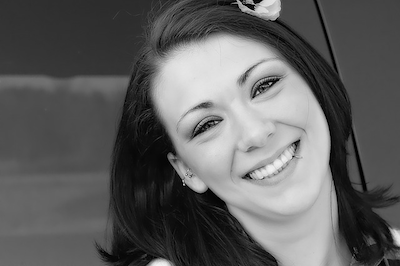

With the mean_filtered applied, the picure turns into the one you see below:

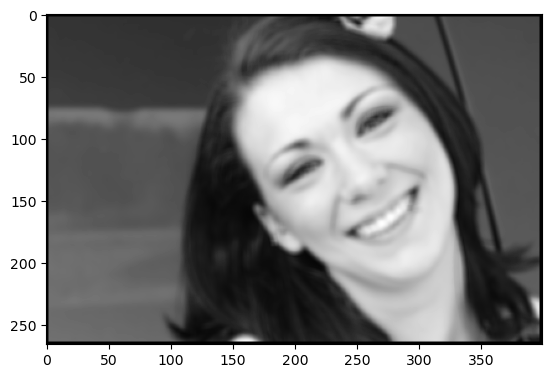

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.18854902, ..., 0.2564706 , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.40862746, ..., 0.10635294, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [544]:
mean_filter('face.png',5)                #applies the mean_filter function with the `face.png` image with s = 5

As you can see, it looks like the picture just looks like a blurry version of what it was before. That is sort of what it is. Since, the image is already clear, there is no noise to really get rid of, instead we're replacing pixels that already don't have noise to them. 

Now if we use  this function on a picture that does have the *salt and pepper* noise mentioned earlier, the results may look different. 

### **when s = 3**

In the example below, the `mean_filter`function below takes the image `ub_noisy1.png` and uses a *3 x 3* square as the determiners of each pixel

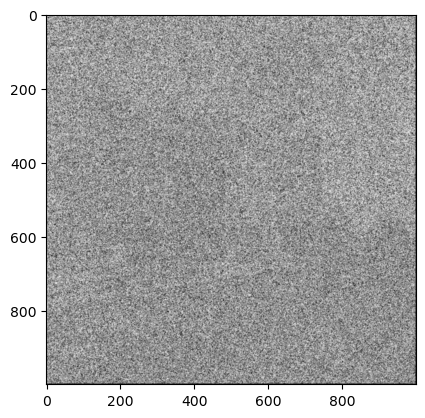

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70457517, 0.70457517, ..., 0.70588236, 0.50762528,
        0.        ],
       [0.        , 0.68540306, 0.54379086, ..., 0.68191722, 0.50762528,
        0.        ],
       ...,
       [0.        , 0.55206972, 0.44357299, ..., 0.61525055, 0.47407408,
        0.        ],
       [0.        , 0.58387801, 0.55250545, ..., 0.72636167, 0.6553377 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [545]:
mean_filter('ub_noisy1.png',3)             #applies the mean_filter function with `ub_noisy1.png` image where s=3

The original picture had much more salt and pepper noise present, whilst now some shadows and outlines of the picture are slightly visible. 

### when s = 5

In the function below, to look at the function and how it reacts to changes in it's parameters, we're changeing the s-variable to 5 instead of 3. The picture however is staying the same. The `s` value changes basically brings more data to find the mean of instead of 9 pixels, there are now 25 pixels

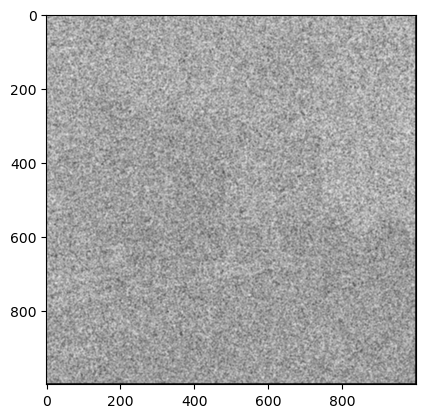

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.58070589, ..., 0.67686275, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.70305883, ..., 0.53756863, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [546]:
mean_filter('ub_noisy1.png',5)               #applies the mean_filter function with the `ub_noisy.png` image where s=5

Similar to before, the picture has less salt and pepper noise than the orginal. However in this one, compared to the last, the salt and pepper in the image is more blurry. The image overall does seem lighter where the lighter colored pixels seems greater thna the number of black/darker colored pixels. The result of this is that the contrast where the shadows in the image were is not great, making it harder to distinguish. 

### when s = 7

In the function below, `mean_filter` has parameters uses the same picture with the `s` variable as 7. So the mean calculation is calculating 49 pixels into determining each pixels of the image. 

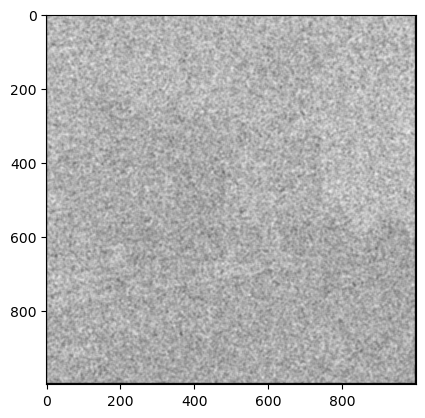

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [547]:
mean_filter('ub_noisy1.png',7)                  #applies the mean_filter function with `ub_noisy1.png` omage where s=7

In the image, the contrast of the dark versus lighter pixles is pretty low, which in turn makes the details and shadows of the image more difficult to see. 

**Mean Filter results**

The mean filter overall, was effective, in terms of de-noising an image that was once so full of noise that the image was unidentifiable. There was a change in the contrast of the image which made the shadows and highlights more visible however, the details of the image were not as visible as one may want it to be. There's no way with confidence someone would say that they can name what place it is using only the `mean_filter` fuction.

Even though the `mean_filter` function wasn't as successful as I may have wished it to be, we still can test a noisy image using the a *median filter*

## Median Filter

The median filter is simillar to the mean filter but obviously the calculation itelf is different, finding the median instead of the mean. To explain the process of this, the function below, `median_filter` goes through each pixel of the image one-by-one where the pixel is in the middle if a *s x s* sized square. Each pixel in the square has a value, determining a color between 0 and 1 where 0 represents black and 1 represents white. The function finds the median, or middle value, if the list of the values, and replaces the value of that pixel with what the median of the *s x s* square array is. 

The goal of the filter is to denoise an image, similar to what the `mean_filter` function was attemping to do. 

In [554]:
def median_filter(img,s):
    image  = find_img(img)                             #loads an image and a 2dim array using previous find_img function
    nrows,ncols = image.shape                          #names variables nrows ,ncols as shape of array values  
    altered_array = np.zeros([nrows,ncols])            #altered array creates empty array of zeros the same shape as 
                                                       #oringinal
    ai,aj = (math.floor(s/2)),math.floor(s/2)          #names ai,aj as the pixel in the sxs array were going through
    median_calc = np.ones((s,s)) / (s**2)              #median calc variable creates sxs array of ones divided by total
                                                       #number of pixels in array to create 'percentage' like numbers 
                                                       #between 0 and 1
    for i in range(ai,nrows-ai):                       #for each row in the image
        for j in range(aj,ncols-aj):                   #and each column in the image
            list_of_pix = []                           #creating an empty list as an initializer for later calulations
            for x in range(-ai,ai+1):                  #for the rows in the sxs array 
                for y in range(-aj,aj+1):              #and the columns in the sxs array
                    list_of_pix.append(image[i+x,j+y]) #were adding the pixel-value to the list
            altered_array[i,j]= np.median(list_of_pix) #we calculate the median of the list and change the pixel of
                                                       #[i,j] in the empty array to what the value of the median was
    plt.imshow(altered_array, cmap = 'gray')           #shows the final altered array but in the gray scale version
    plt.show() 
    return altered_array                               #returns the altered array

### Examples

#### when s = 3

In the `median_filter` below, it's the same image as it was used in the examples above with the `mean_filter`. The median filter is using the `s` variable is 3, so the median filter is uses 9 pixels to determine the median value. 

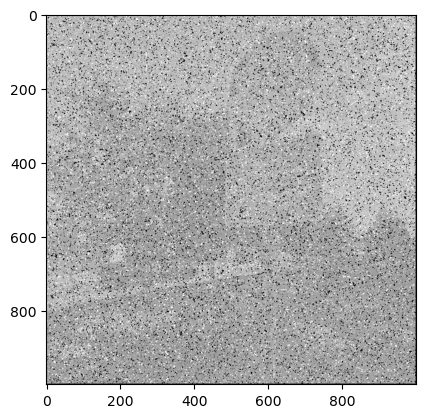

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.72549021, 0.72549021, ..., 0.78431374, 0.78431374,
        0.        ],
       [0.        , 0.72549021, 0.72156864, ..., 0.78431374, 0.78431374,
        0.        ],
       ...,
       [0.        , 0.65882355, 0.65882355, ..., 0.63529414, 0.63137257,
        0.        ],
       [0.        , 0.64705884, 0.65882355, ..., 0.63529414, 0.63529414,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [549]:
median_filter('ub_noisy1.png',3)                #applies the median_filter function with `ub_noisy1.png` image where s=3

The result of the image after the `median_filter` had been applied is an image with a pretty good amount of contrast along that the image isn't very blurry yet. Although, I wouldn't say that somone could easily identify what the picture is out of. I would say the details are a bit more visible than they were with the `mean_filter`.

### when s = 6

In the example below, the same `median_filter` is being applied. Where the *s x s* square array is of a 36-pixel array where the median of all of the values will replace the center-most value of the image

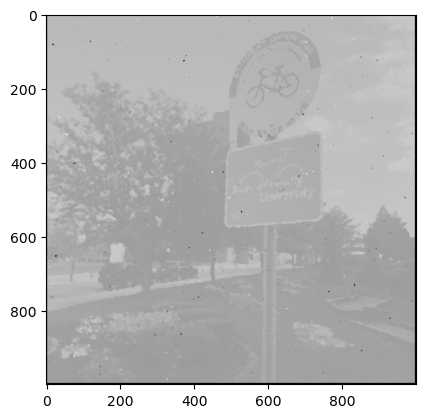

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [550]:
median_filter('ub_noisy1.png',6)              #applies the median_filter function with `ub_noisy1.png` image where s=6

From the example, by using the `median_filter` function, the details of the image are much more visible. Even though there are still some pepper noise pixels visible the image is relatively identafiable to the human eye. The bycicle on the sign in the foregrounf of the picture is visible even though the words on it arent as readable as they would be optimally.

### when s = 16

In the example below, the `median_filter` is using the same image but the value of `s` is 16 so the *s x s* array goes throuhg each pixel, determines the median of that array and replaces that pixel with the calculated median value.

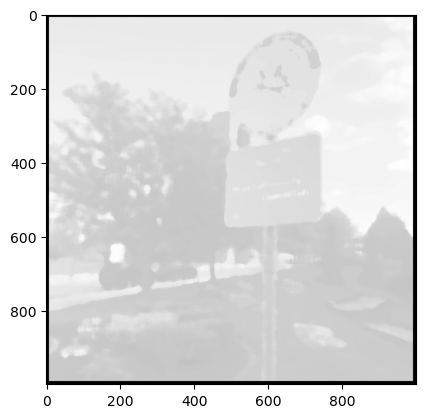

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [552]:
median_filter('ub_noisy1.png',16)              #applies the median_filter function with `ub_noisy1.png` image where s=16

the results of the function from above no longer has any remaining pepper and salt noise, however the details are not as visible and the contrast of the whole image seemed to increase, making it harder to confidently distinguish anything from it.

### Median Filter results

The mean filter was also affective in de-noising an image and taking away the salt and pepper noise pixels. The image that was once fully salt and pepper noise now is somewhat identifiable.It seems as though the optimal range for the `s` value in the `median_filter` function would be from 3-9.

## Conclusion

### Noise in images

An image that has randomly placed salt and pepper pixels, where the percentage of pixels that are noise is the facotr that deems how *noisy* an image would be considered. To create noise we created a function, `sp_noise` where part of the input is a percentage where half of it would be the percentage of salt(white) noise pixels, and the other half pepper(black) noise pixels. 

### Denoising images

To denoise an image, we first need a noisy image. Where at least some of the pixels are salt and pepper noise pixels. In the examples we used in this project, the original imgaes to denoise were almost unidentifiable, as the only visible thing were the salt and pepper pixels. There were two methods that we used to denoise the images to make them clearer and more identifyable to the human eye. We used a **Mean Filter** and a **Median Filter**. 

For each filter we made a function that calculated the mean of an *s x s* square array surrounding the pixel we want the alter, one by one. The difference in the filters is that for the `mean_filter` function, we're finding the mean value of the pixels and with the `median_filter ` function, we're finding the median value of tthe pixels to replace the center pixel with.

In each of the examples for the functions, I kept the same image, `ub_noisy1.png` and ony changed the value of the `s` variable. The `s` variable can be an even number, however an odd number would make more sense, as the *s x s* array would have a center pixel. The opimal `s` numbers for both functions, I would say range from 3-9, but 5 may be the most optimal.

### Effectiveness of the filter


#### Denoising images with no noise

As shown in the very beginning of this project, we can use these filters on any image. Below is the functions `mean_filter` and `median_filter` with the original `face.png` image that doesn't have any salt or pepper noise

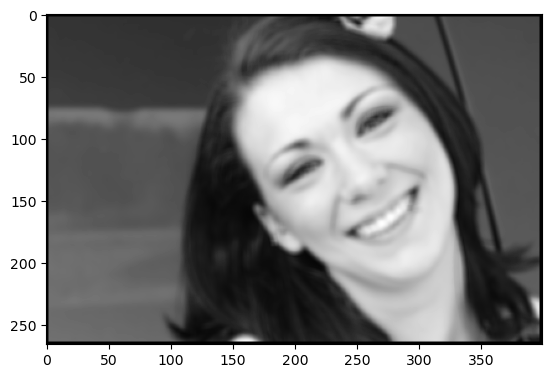

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.18854902, ..., 0.2564706 , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.40862746, ..., 0.10635294, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [556]:
mean_filter('face.png',5)                              #applies the mean_filter function with `face.png` image where s=5

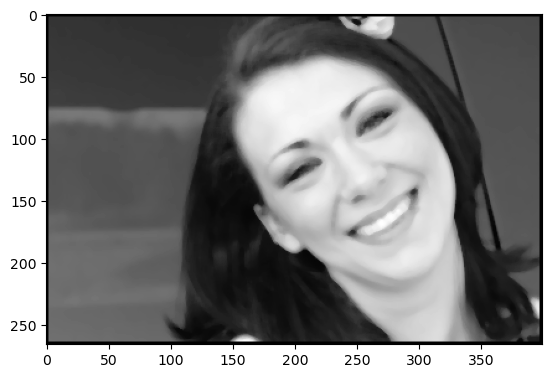

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.1882353 , ..., 0.25490198, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.40784314, ..., 0.10588235, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [557]:
median_filter('face.png',5)                    #applies the median_filter function with `face.png` image where s =5

We can see that on an already clear picture it seems as though the picture is getting blurrier or as though there's a smoothing affect of the image.

Although both the **Median Filter** and **Mean Filter** had the same goal, I'd say that the effectiveness of each function was not the same. Objectively the end image of the `median_filter` was more clear and it's details were more identifiable than the `mean_filter` was. The `median_filter` actually ended up getting rid of the noise that the image was originally full of. However, in the `mean_filter` the noise never really went away, it just got blurrier and blended into the picture making the image more difficult to see. 

Even though the Mean Filter did accomplish the goal, I think that the image could still be clearer. We could alter the code to maybe repeat the function until a certain point and maybe since we discovered the `s = 5` was the most successful, keep doing that process of the filter until a certain point. This could potentially make the details more clear and more precise. 